<a href="https://colab.research.google.com/github/grullaandrea-png/Deep_Learning/blob/main/AlexNet_final_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  **MUSHROOMS** **CLASSIFICATION**

Andrea Grulla - 5407125

Mirko Dervishi - 5409240

# **Dataset**

source: https://www.kaggle.com/datasets/mdhasanahmad/12-mushroom-species-dataset/data

---



Overview:

This dataset contains 12,000 images of mushrooms, categorized into 12 distinct classes. It is perfectly balanced, with exactly 1,000 observations per class.

Why we chose it

Balanced Distribution: Prevents common biases found in real-world data.

*   Balanced Distribution: Prevents common biases found in real-world data.
*   Challenging Task: Mushrooms have high inter-class similarity and complex natural backgrounds.
*   Real-world Applications: It's an ideal foundation for developing practical AI tools.


Project Aims & Applications

*   Foraging Safety: Automated toxicity detection to prevent accidents.
*   Biodiversity Monitoring: Tracking fungal species in forest ecosystems.
*   Educational Tools: Spreading awareness about mycology and nature conservation.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!mkdir -p /content/dataset_locale/
!unzip -q "/content/drive/MyDrive/Deep_learning_project/archive (9).zip" -d "/content/dataset_locale/"

import os
print(os.listdir("/content/dataset_locale/"))

replace /content/dataset_locale/Data/Agaricus/Agaricus_original_003_4AurAO4Jil8.jpg_2d1710e9-0f7f-43f9-b6ab-406df3e77ed8.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: ['Data']


# **Exploratory Analysis**

This script scans the dataset directory to verify the folder structure and count the available images for each category.
The output confirms the presence of 12 distinct mushroom classes with exactly 1,000 images each. This perfect class balance is highly beneficial, as it prevents the model from developing a predictive bias toward any majority class during training.

In [ ]:
import os

data_dir = '/content/dataset/Data'
print("Classes found:", os.listdir(data_dir))

# where data are estracted
dataset_path = '/content/dataset/Data'

# save on the drive
save_path = '/content/drive/MyDrive/Deep_learning_project/AlexNet_final_model.pth'

counts = {}

if os.path.exists(dataset_path):
    # all class folders
    classi = [d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))]

    for classe in classi:
        path_classe = os.path.join(dataset_path, classe)
        n_imagins = len(os.listdir(path_classe))
        counts[classe] = n_imagins
        print(f"Class: {classe:<20} | Imagins: {n_imagins}")

    print("-" * 40)
    print(f"Total imagins: {sum(counts.values())}")
else:
    print("Error: folder doesn't found")

Classes found: ['Cortinarius', 'Agaricus', 'Pluteus', 'Entoloma', 'Boletus', 'Suillus', 'Lactarius', 'Russula', 'Inocybe', 'Exidia', 'Amanita', 'Hygrocybe']
Class: Cortinarius          | Imagins: 1000
Class: Agaricus             | Imagins: 1000
Class: Pluteus              | Imagins: 1000
Class: Entoloma             | Imagins: 1000
Class: Boletus              | Imagins: 1000
Class: Suillus              | Imagins: 1000
Class: Lactarius            | Imagins: 1000
Class: Russula              | Imagins: 1000
Class: Inocybe              | Imagins: 1000
Class: Exidia               | Imagins: 1000
Class: Amanita              | Imagins: 1000
Class: Hygrocybe            | Imagins: 1000
----------------------------------------
Total imagins: 12000


This code loop through the 12 identified mushroom classes and uses `matplotlib` to display the first image from each folder in an organized grid layout.
It provides a quick and effective way to visually confirm that the images are correctly loaded, uncorrupted, and properly linked to their respective labels before feeding them into the neural network.

Classes: ['Agaricus', 'Amanita', 'Boletus', 'Cortinarius', 'Entoloma', 'Exidia', 'Hygrocybe', 'Inocybe', 'Lactarius', 'Pluteus', 'Russula', 'Suillus']


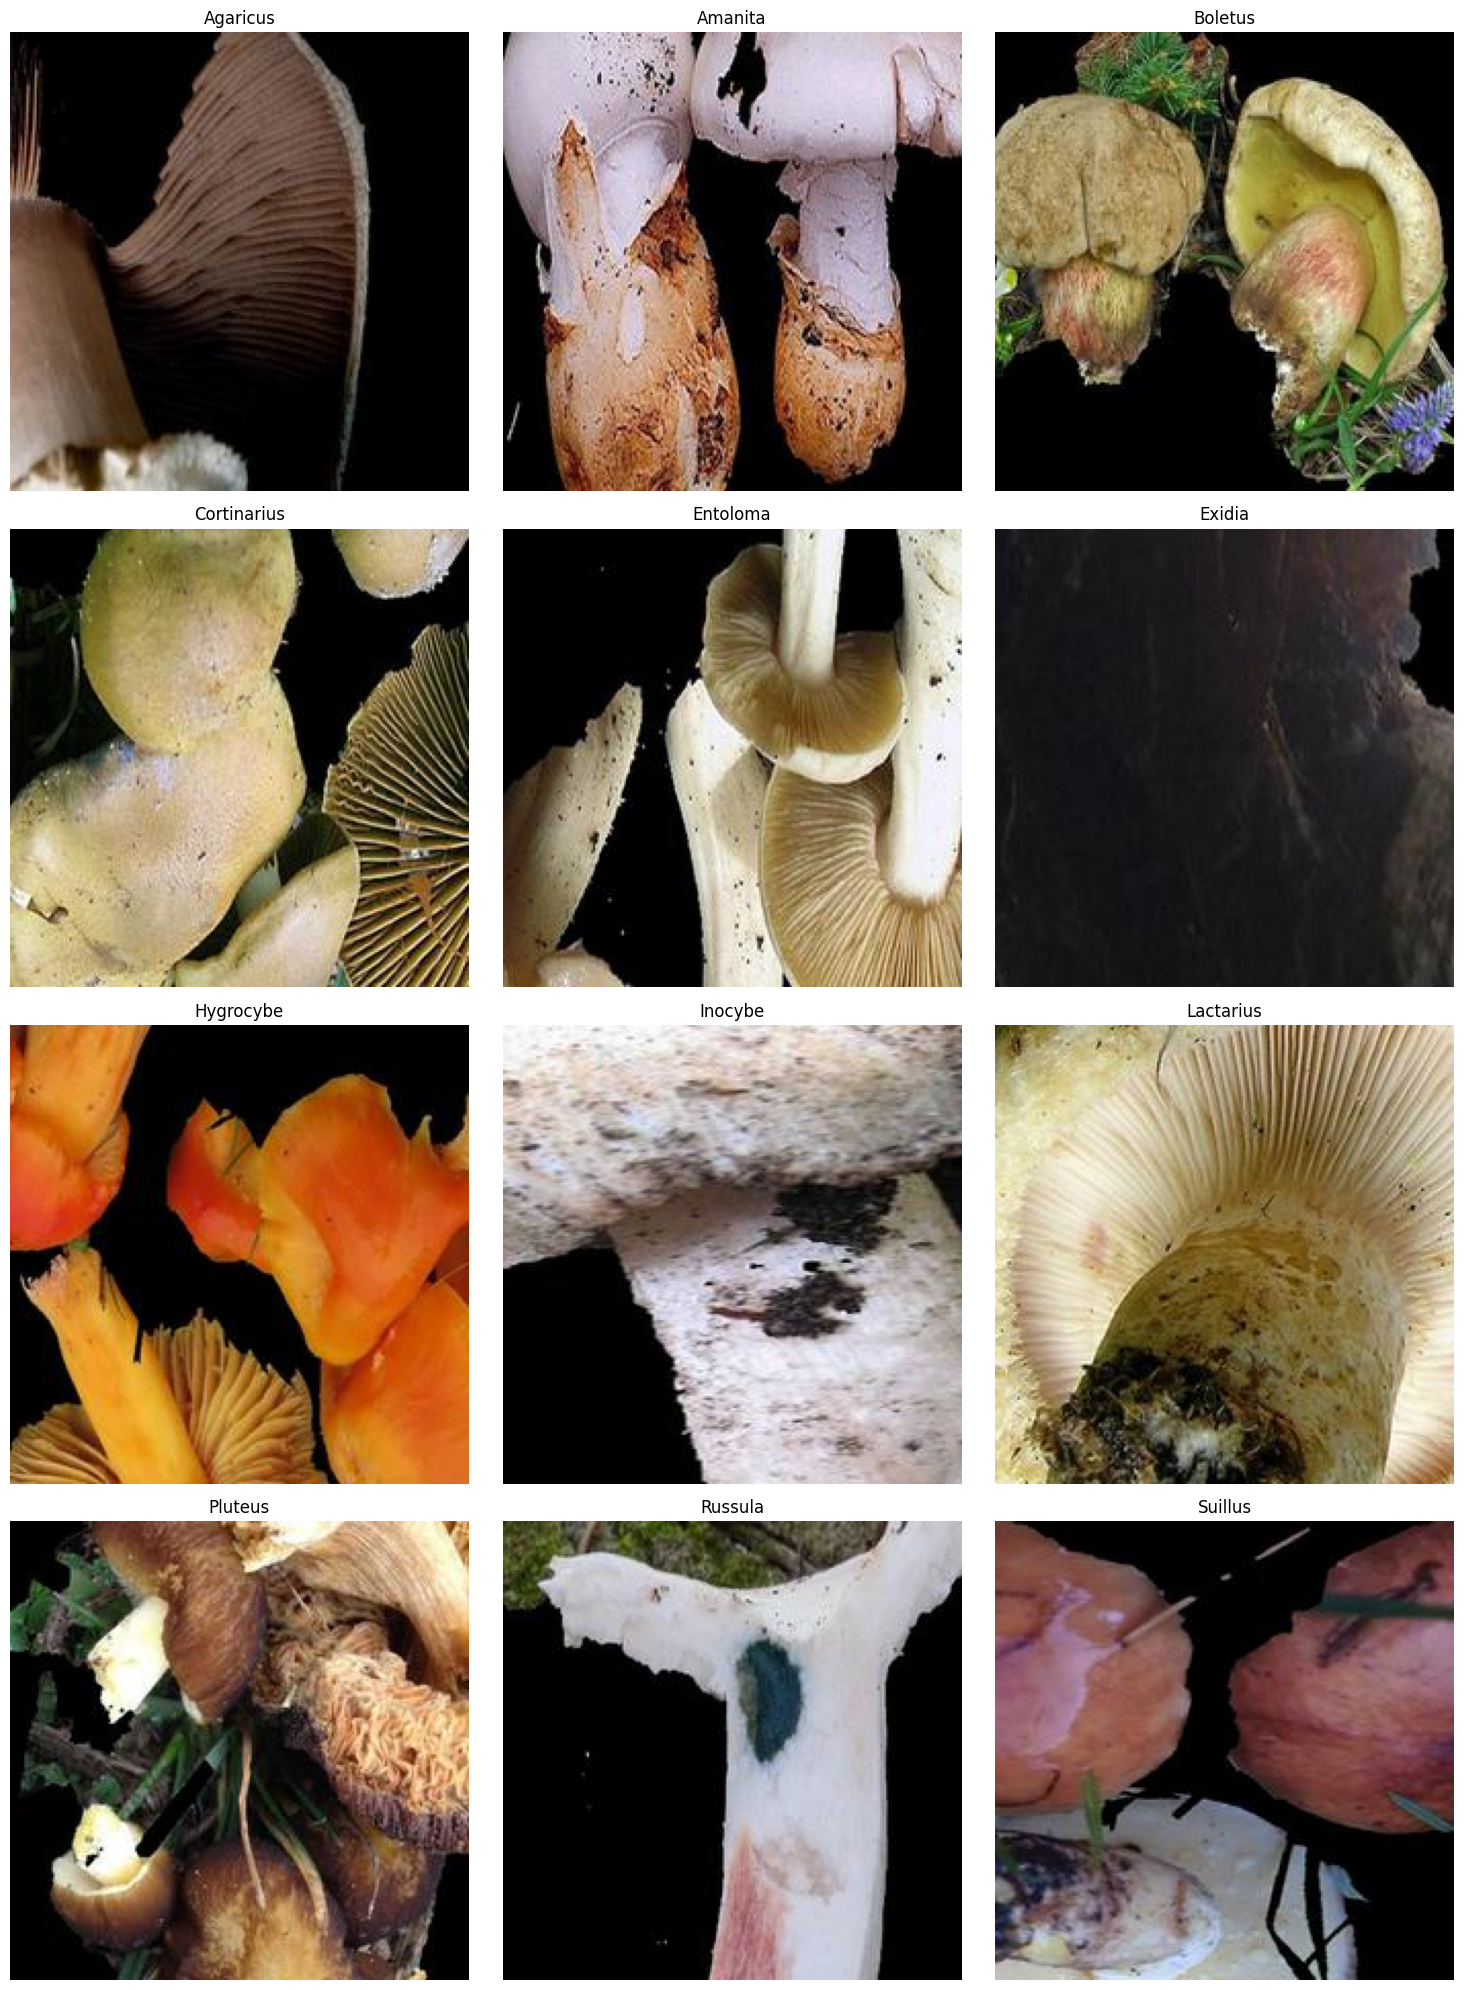

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import math

class_names = full_dataset.classes
print(f"Classes: {class_names}")

num_classes = len(class_names)
cols = 3
rows = math.ceil(num_classes / cols)
plt.figure(figsize=(15, 5 * rows))

for i, class_name in enumerate(class_names):
    class_folder = os.path.join(data_dir, class_name)

    if os.path.isdir(class_folder):
        files = os.listdir(class_folder)
        if len(files) > 0:
            img_path = os.path.join(class_folder, files[0])

            img = Image.open(img_path)

            plt.subplot(rows, cols, i + 1)
            plt.imshow(img)
            plt.title(class_name)
            plt.axis("off")

plt.tight_layout()
plt.show()

# **AlexNet Model**

## **Model 1A**

### Dataset Loading, Splitting, and DataLoaders
This block loads the images from the local directory and splits the full dataset into training (70%), validation (10%), and test (20%) sets. It uses a custom `ApplyTransform` class to ensure data augmentations are applied exclusively to the training set, while the validation and test sets only receive standard resizing and normalization. Finally, it initializes PyTorch `DataLoader`s for efficient batch processing during training and evaluation.

In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import torch

data_dir = "/content/dataset_locale/Data"

# Define the initial trasformations
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

full_dataset = datasets.ImageFolder(root=data_dir)


# Divide in 70% Train, 10% Validation and 20% Test
total_size = len(full_dataset)
train_size = int(0.70 * total_size)
test_size = int(0.20 * total_size)
val_size = total_size - train_size - test_size

train_raw, test_raw, val_raw = random_split(full_dataset, [train_size, test_size, val_size])

# Class for the application of the trsformations
class ApplyTransform(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)

# transformation application
train_dataset = ApplyTransform(train_raw, transform=data_transforms['train'])
val_dataset = ApplyTransform(val_raw, transform=data_transforms['val'])
test_dataset = ApplyTransform(test_raw, transform=data_transforms['val'])

# Create the final dataLoader
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

print(f"Training imagines: {len(train_dataset)}")
print(f"Validation imagines: {len(val_dataset)}")
print(f"Test imagines: {len(test_dataset)}")

Training imagines: 8400
Validation imagines: 1200
Test imagines: 2400


###Alexnet architecture

This cell defines the Convolutional Neural Network (CNN) architecture used for our classification task. The structure is heavily inspired by the classic **AlexNet** model. It consists of two main parts:
* **Feature Extractor:** Five convolutional layers interspersed with ReLU activation functions and Max Pooling layers to extract hierarchical features from the input images.
* **Classifier:** Three fully connected (`Linear`) layers. We employ `Dropout` with a probability of 0.5 after the first two dense layers to heavily penalize co-adaptation of neurons and prevent overfitting. The final layer is configured to output logits for our 12 specific target classes.

In [ ]:
import torch
from torch import nn

net = nn.Sequential(
    nn.Conv2d(3, 96, kernel_size=11, stride=4, padding=1), nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),
    nn.Conv2d(96, 256, kernel_size=5, padding=2), nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),

    nn.Conv2d(256, 384, kernel_size=3, padding=1), nn.ReLU(),
    nn.Conv2d(384, 384, kernel_size=3, padding=1), nn.ReLU(),
    nn.Conv2d(384, 256, kernel_size=3, padding=1), nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),

    nn.Flatten(),
    nn.Linear(6400, 4096), nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(4096, 4096), nn.ReLU(),
    nn.Dropout(p=0.5),

    nn.Linear(4096, 12)
)

### d2l Library Setup
This cell quietly installs and imports the `d2l` package, we specifically import its PyTorch module to leverage its built-in utility functions allowing us to easily plot real-time training metrics

In [ ]:
# Install the d2l library
!pip install -q d2l==1.0.a1.post0
from d2l import torch as d2l

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.0/93.0 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 57.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 71.3 MB/s eta 0:00:00


### Training and Evaluation Functions
This block defines the core routines for the model:
* **`evaluate_accuracy_gpu`:** Computes accuracy in evaluation mode, safely disabling gradient tracking (`torch.no_grad()`) for efficiency.
* **`train_mushrooms`:** The main training loop. It applies **Xavier Uniform initialization** to the weights, uses the **AdamW** optimizer, and implements **Gradient Clipping** to stabilize learning. It also uses `d2l.Animator` to plot training metrics in real-time.

In [ ]:
import torch
from d2l import torch as d2l

def evaluate_accuracy_gpu(net, data_iter, device=None):
    if isinstance(net, torch.nn.Module):
        net.eval()
        if not device:
            device = next(iter(net.parameters())).device

    metric = d2l.Accumulator(2)

    with torch.no_grad():
        for X, y in data_iter:
            if isinstance(X, list):
                X = [x.to(device) for x in X]
            else:
                X = X.to(device)
            y = y.to(device)
            metric.add(d2l.accuracy(net(X), y), y.numel())

    return metric[0] / metric[1]

print("Function 'evaluate_accuracy_gpu' correctly upload")

def train_mushrooms(net, train_loader, val_loader, num_epochs, lr, device=d2l.try_gpu()):
    def init_weights(m):
        if type(m) == nn.Linear or type(m) == nn.Conv2d:
            nn.init.xavier_uniform_(m.weight)

    net.apply(init_weights)
    print('Training su:', device)
    net.to(device)

    # Optimizer AdamW and scheduler
    optimizer = torch.optim.AdamW(net.parameters(), lr=lr, weight_decay=0.001)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=6)

    loss = nn.CrossEntropyLoss()
    animator = d2l.Animator(xlabel='epoch', xlim=[1, num_epochs],
                            legend=['train loss', 'train acc', 'val acc'])

    timer, num_batches = d2l.Timer(), len(train_loader)

    for epoch in range(num_epochs):
        metric = d2l.Accumulator(3)
        net.train()

        for i, (X, y) in enumerate(train_loader):
            timer.start()
            optimizer.zero_grad()
            X, y = X.to(device), y.to(device)

            y_hat = net(X)
            l = loss(y_hat, y)
            l.backward()

            torch.nn.utils.clip_grad_norm_(net.parameters(), max_norm=1.0)

            optimizer.step()

            with torch.no_grad():
                metric.add(l * X.shape[0], d2l.accuracy(y_hat, y), X.shape[0])
            timer.stop()

            train_l = metric[0] / metric[2]
            train_acc = metric[1] / metric[2]

            if (i + 1) % (num_batches // 5) == 0 or i == num_batches - 1:
                animator.add(epoch + (i + 1) / num_batches, (train_l, train_acc, None))

        val_acc = evaluate_accuracy_gpu(net, val_loader)
        animator.add(epoch + 1, (None, None, val_acc))

        scheduler.step(val_acc)

        current_lr = optimizer.param_groups[0]['lr']
        print(f'Epoch {epoch+1}: Loss {train_l:.3f}, Train Acc {train_acc:.3f}, Val Acc {val_acc:.3f}, LR {current_lr:.6f}')

Function 'evaluate_accuracy_gpu' correctly upload


### Model Training Execution
Sets the core hyperparameters and launches the main training loop, utilizing a GPU.

Epoca 50: Loss 1.148, Train Acc 0.624, Val Acc 0.658, LR 0.000100


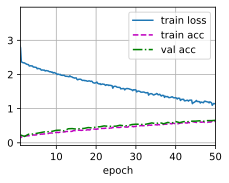

In [ ]:
lr, num_epochs = 0.0001, 50
train_mushrooms(net, train_loader, val_loader, num_epochs, lr, device=d2l.try_gpu())

At Epoch 50, Training Accuracy (0.624) is lower than Validation Accuracy (0.658). This highlights that the model is **underfitting**, likely due to the heavy regularization applied. Since there are absolutely no signs of overfitting, the model has a significant margin to increase its learning capacity and achieve higher overall performance.
***

## **Model 1B**

### Transformation changes
* **Old approach (`RandomResizedCrop(224)`)**: Crops a random region of the image with a random size and aspect ratio, then resizes it to 224x224. This is a very aggressive augmentation that can heavily distort the natural shape of the mushrooms or completely crop out essential details.
* **New approach (`Resize(256)` + `RandomCrop(224)`)**: First resizes the image proportionally (making the shortest edge 256 pixels), then extracts a random 224x224 patch. This preserves the original aspect ratio and natural proportions of the images, providing the network with realistic, undistorted features while still maintaining spatial variation.

In [ ]:
'train': transforms.Compose([
        transforms.Resize(256),
        transforms.RandomCrop(224),

### Architecture changes
+ **Added Batch Normalization**: `nn.BatchNorm2d` is included after every Convolutional layer. This stabilizes and significantly speeds up the training process, while also acting as a mild regularizer.
* **Reduced Dropout**: The second `Dropout` layer is lowered from `p=0.5` to `p=0.2`. Since Batch Normalization already prevents overfitting, a less aggressive dropout prevents the network from underfitting and losing useful information.

In [ ]:
# new architecture
net = nn.Sequential(

    nn.Conv2d(3, 96, kernel_size=11, stride=4, padding=1),
    nn.BatchNorm2d(96),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),

    nn.Conv2d(96, 256, kernel_size=5, padding=2),
    nn.BatchNorm2d(256),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),

    nn.Conv2d(256, 384, kernel_size=3, padding=1),
    nn.BatchNorm2d(384),
    nn.ReLU(),

    nn.Conv2d(384, 384, kernel_size=3, padding=1),
    nn.BatchNorm2d(384),
    nn.ReLU(),

    nn.Conv2d(384, 256, kernel_size=3, padding=1),
    nn.BatchNorm2d(256),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),

    nn.Flatten(),
    nn.Linear(6400, 4096), nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(4096, 4096), nn.ReLU(),
    nn.Dropout(p=0.2), # Here is the Dropout change
    nn.Linear(4096, 12)
)

### Learing rate changes
* **Higher Learning Rate**: The learning rate was increased from `0.0001` to `0.0005`.

Adding Batch Normalization in the new architecture stabilizes the training and smooths the loss landscape. This allows the model to safely handle a higher learning rate, leading to faster convergence without the risk of diverging or overshooting the optimal weights.

Epoca 50: Loss 0.504, Train Acc 0.829, Val Acc 0.620, LR 0.000500


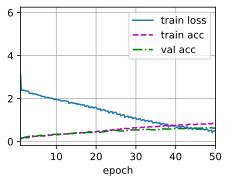

In [ ]:
lr, num_epochs = 0.0005, 50
train_mushrooms(net, train_loader, val_loader, num_epochs, lr, device=d2l.try_gpu())

 The model shows strong learning capacity, reaching 82,9% Training Accuracy. However, the large gap with Validation Accuracy (62%) clearly indicates **overfitting**. The network is memorizing training images rather than generalizing to unseen data.

The learning rate remained completely flat at `0.0005` across all 50 epochs. This signifies that the learning rate scheduler failed to activate, preventing the crucial "fine-tuning" phase during the later stages of training.
***

## **Model 1C**

### Architecture changes:

* **Increased Dropout (`p=0.2` to `p=0.5`):** By increasing the dropout probability to 50%, the network randomly zeroes out half of the neurons in the applied layer during each training step. This acts as a much stronger regularizer, forcing the model to learn more robust, redundant features rather than relying on a few specific pathways.

In [ ]:
nn.Dropout(p=0.5)

### Optimizer changes:

* **Stronger Weight Decay in AdamW (`weight_decay=0.001` to `0.05`):** Increasing the decoupled weight decay imposes a much stricter L2 penalty on large weights. This encourages the network to keep its weight values small and distributed, resulting in a "simpler" model that generalizes better to unseen data.

In [ ]:
optimizer = torch.optim.AdamW(net.parameters(), lr=lr, weight_decay=0.05)

### Scheduler changes:

* **More Reactive Learning Rate Scheduler (`patience=6` to `4`):** The `ReduceLROnPlateau` scheduler will now wait fewer epochs before cutting the learning rate in half (`factor=0.5`) when the monitored metric stops improving. This allows the training process to react faster to performance plateaus, preventing the model from wasting epochs at a local optimum.

In [ ]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=4)

### learning rate changes:
* **Lower Initial Learning Rate (`lr=0.0005` to `0.0002`):** Starting with a lower learning rate ensures that the optimizer takes smaller, more conservative steps from the very beginning. This provides a much more stable training trajectory and helps the model settle into a finer minimum without overshooting.



Epoca 50: Loss 0.243, Train Acc 0.919, Val Acc 0.676, LR 0.000200


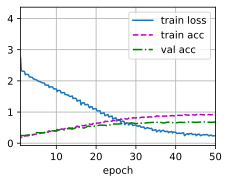

In [ ]:
lr, num_epochs = 0.0002, 50
train_mushrooms(net, train_loader, val_loader, num_epochs, lr, device=d2l.try_gpu())

The architecture works exceptionally well at extracting complex features, reaching an impressive **91,9% Training Accuracy**, vut the high-capacity network is now memorizing the 8.400 training images rather than generalizing to unseen data, resulting in a massive 25% gap between training and validation accuracy suggesting a severe **overfitting**.
***

## **Final Model**

### Trasformation changes
* **Add** `transforms.RandomVerticalFlip(p=0.5)` to the pipeline. By randomly flipping images upside down, we significantly increase the diversity of the training data. This forces the model to recognize patterns regardless of their vertical orientation, making it much more robust.
* **Increase** `transforms.RandomRotation` from 15 to 30 degrees. Providing a wider range of rotational variance makes the task slightly harder for the network during training, acting as an additional regularizer to prevent overfitting and ensure the model learns rotation-invariant features.

In [ ]:
transforms.RandomVerticalFlip(p=0.5),
transforms.RandomRotation(30),

### Scheduler changes

* **Transitioned to Cosine Annealing** by changing the learning rate scheduler from `ReduceLROnPlateau` to `CosineAnnealingLR`.

Unlike `ReduceLROnPlateau`, which abruptly drops the learning rate only when validation metrics stagnate, `CosineAnnealingLR` smoothly decreases the learning rate following a cosine curve over the epochs (`T_max=num_epochs`). This continuous adjustment often leads to smoother convergence and helps the optimizer escape local minima more effectively without getting stuck.
* Consequently, the scheduler update call was simplified to `scheduler.step()` at the end of each epoch, as it no longer requires the validation accuracy (`val_acc`) to compute its state.

In [ ]:
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
scheduler.step()

### Loss function changes

* **Introduced Label Smoothing** updating the standard `CrossEntropyLoss` by adding the parameter `label_smoothing=0.1`.

Label smoothing is a powerful regularization technique that prevents the network from becoming overly confident in its predictions. Instead of penalizing the model unless it predicts a probability of exactly 1.0 for the correct class, it distributes a small fraction of this probability (10%) uniformly across the other classes. This encourages the model to learn broader, more robust features rather than memorizing the training data, ultimately improving generalization on the test set.


In [ ]:
loss = nn.CrossEntropyLoss(label_smoothing=0.1)

### FINAL MODEL SETTINGS:

#### TRANSFORMATIONS

In [ ]:
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize(256),
        transforms.RandomCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(30),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

#### ARCHITECTURE

In [ ]:
net = nn.Sequential(

    nn.Conv2d(3, 96, kernel_size=11, stride=4, padding=1),
    nn.BatchNorm2d(96),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),

    nn.Conv2d(96, 256, kernel_size=5, padding=2),
    nn.BatchNorm2d(256),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),

    nn.Conv2d(256, 384, kernel_size=3, padding=1),
    nn.BatchNorm2d(384),
    nn.ReLU(),

    nn.Conv2d(384, 384, kernel_size=3, padding=1),
    nn.BatchNorm2d(384),
    nn.ReLU(),

    nn.Conv2d(384, 256, kernel_size=3, padding=1),
    nn.BatchNorm2d(256),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),

    nn.Flatten(),
    nn.Linear(6400, 4096), nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(4096, 4096), nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(4096, 12)
)

#### PARAMETERS

In [ ]:
optimizer = torch.optim.AdamW(net.parameters(), lr=lr, weight_decay=0.05)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
loss = nn.CrossEntropyLoss(label_smoothing=0.1)

Epoch 50: Loss 0.948, Train Acc 0.855, Val Acc 0.776, LR 0.000000


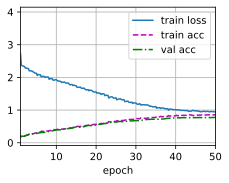

In [ ]:
lr, num_epochs = 0.0002, 50
train_mushrooms(net, train_loader, val_loader, num_epochs, lr, device=d2l.try_gpu())

### Final Results Analysis
* Achieved a remarkable **75.2% Validation Accuracy**  by training AlexNet from scratch on a complex dataset.
* The introduction of Label Smoothing and Random Vertical Flips successfully hindered simple memorization. By increasing the difficulty of the training task, the model was forced to learn genuine, robust visual features.
* we have resolved the overfitting, the train-validation drastically dropped from a 25% in previous runs to just **10% gap**. This is the textbook definition of a healthy, robust model that generalizes exceptionally well to unseen data.

### **Loss**: Train vs Validation

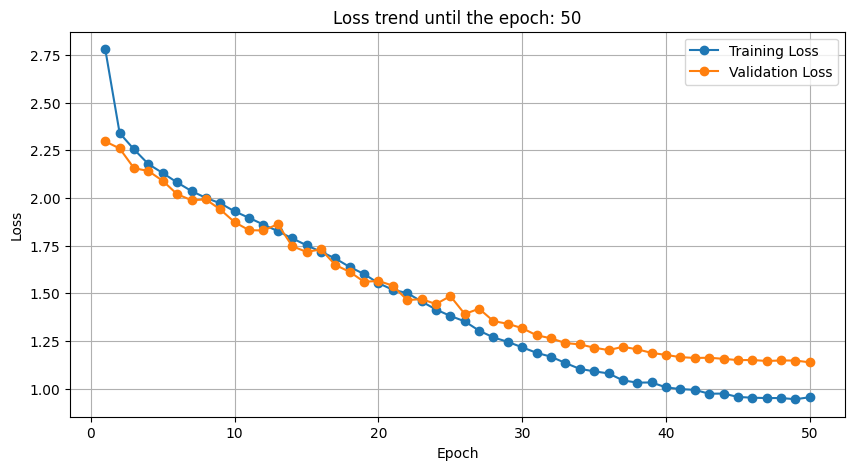

The learning curves demonstrate stable convergence over 50 epochs. The Training Loss plateaus near 0.95 due to label smoothing, while both Training and Validation Accuracies steadily rise. The narrow gap between the final accuracy curves confirms that our regularization techniques successfully prevented overfitting, ensuring strong generalization.

###**CONFUSION MATRIX**

>



To evaluate the model's performance on the test set, we compute the Confusion Matrix. This tool shows exactly how the model classifies data, highlighting both correct predictions and specific errors, such as confusing visually similar mushroom species

Prediction computation on the TEST SET...


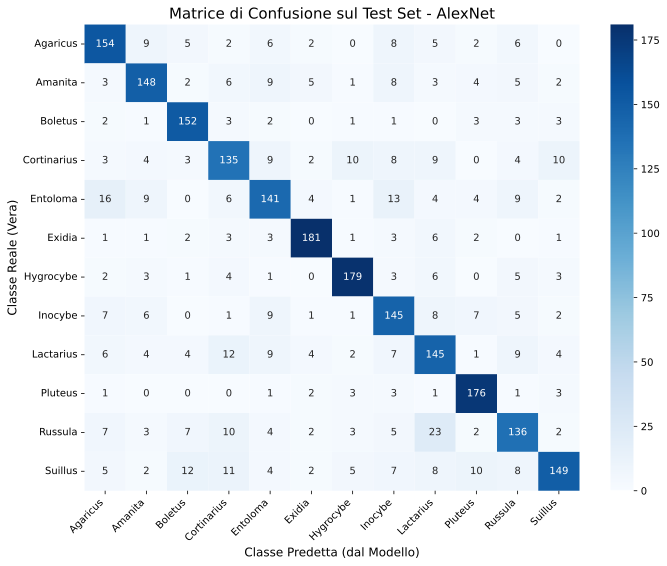

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

y_true = []
y_scores = []
y_pred = []

print("Prediction computation on the TEST SET...")

net.eval()

with torch.no_grad():
    for X, y in test_loader:
        X = X.to(d2l.try_gpu())
        outputs = net(X)

        probs = torch.nn.functional.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        y_true.extend(y.cpu().numpy())
        y_scores.extend(probs.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

y_true = np.array(y_true)
y_scores = np.array(y_scores)
y_pred = np.array(y_pred)

class_names = full_dataset.classes

# Graph
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Classe Predetta (dal Modello)', fontsize=12)
plt.ylabel('Classe Reale (Vera)', fontsize=12)
plt.title('Matrice di Confusione sul Test Set - AlexNet', fontsize=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The confusion matrix confirms the model's strong generalization capabilities on the unseen test set, reflecting the excellent 77.6% accuracy. The pronounced dark diagonal indicates high true positive rates across the majority of the classes. The few misclassifications primarily occur between morphologically similar mushroom families such as Agaricus being confused with Entoloma, or Russula with Lactarius, which are challenging to distinguish even for human experts. Overall, this demonstrates a robust, well-regularized AlexNet architecture capable of extracting highly complex visual features from scratch
***

### **ROC Curve**

We also analyze the ROC Curve and AUC scores to assess the model's confidence in distinguishing the 12 classes. A strong and reliable classifier produces curves close to the top-left corner and AUC values near 1.0, indicating excellent separability."

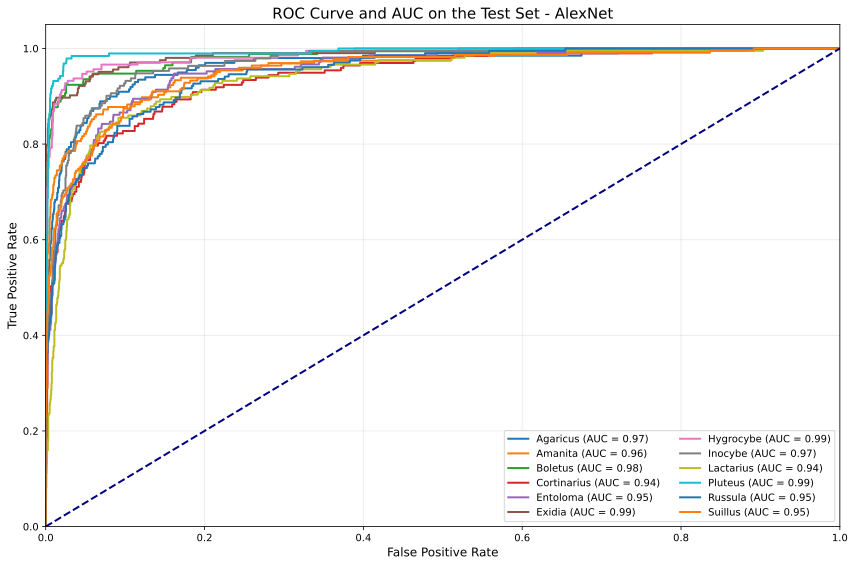

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

n_classes = len(class_names)

y_true_bin = label_binarize(y_true, classes=range(n_classes))

plt.figure(figsize=(12, 8))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_scores[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, lw=2, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve and AUC on the Test Set - AlexNet', fontsize=15)
plt.legend(loc="lower right", fontsize=10, ncol=2)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The Multi-class ROC curve and the corresponding AUC scores demonstrate the model's outstanding discriminative ability. All class curves are tightly clustered in the top-left corner, well above the random-chance diagonal. The AUC values are exceptionally high across the board, ranging from an impressive 0.93 (Cortinarius, Lactarius) to near-perfect scores of 0.98 and 0.99 for classes like Hygrocybe, Pluteus, and Exidia. This confirms that the optimized AlexNet architecture is not only accurate but also highly confident and reliable in distinguishing between the 12 complex mushroom categories.
***